# Exploratory Data Analysis (EDA) & Data Cleaning

This notebook performs a deep dive into the provided image dataset to identify and resolve issues such as class imbalance, rò rỉ dữ liệu (leaks), and duplicate images with conflicting labels.

In [1]:
import os
import hashlib
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Helper Functions for Metadata & Visuals

In [2]:
def get_image_info(img_path):
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            mode = img.mode
            format = img.format
            return width, height, mode, format
    except Exception as e:
        return None, None, None, str(e)

def calculate_hash(img_path):
    hash_md5 = hashlib.md5()
    with open(img_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

def scan_dataset(data_dir):
    data = []
    if not os.path.exists(data_dir): return pd.DataFrame()
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    
    for cls in classes:
        cls_path = os.path.join(data_dir, cls)
        files = os.listdir(cls_path)
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp', '.bmp')):
                img_path = os.path.join(cls_path, f)
                w, h, m, fmt = get_image_info(img_path)
                md5 = calculate_hash(img_path)
                data.append({
                    'split': os.path.basename(data_dir),
                    'class': cls,
                    'filename': f,
                    'path': img_path,
                    'width': w,
                    'height': h,
                    'aspect_ratio': round(w / h, 2) if h and h > 0 else 0,
                    'mode': m,
                    'format': fmt,
                    'md5': md5,
                    'size_kb': os.path.getsize(img_path) / 1024
                })
    return pd.DataFrame(data)

def display_conflict_images(df, md5_list, title="Conflict Comparison"):
    for md5 in md5_list:
        group = df[df['md5'] == md5].sort_values('split')
        n = len(group)
        fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
        if n == 1: axes = [axes]
        
        display(HTML(f"<div style='background-color:#fff5f5; padding:10px; border-radius:5px;'><b>Hash: {md5}</b></div>"))
        
        for i, (_, row) in enumerate(group.iterrows()):
            img = Image.open(row['path'])
            axes[i].imshow(img)
            axes[i].set_title(f"Split: {row['split']}\nClass: {row['class']}\n{row['filename']}", fontsize=10)
            axes[i].axis('off')
        plt.tight_layout()
        plt.show()
        print(f"Paths involved for {md5}:")
        for p in group['path'].tolist():
            print(f"'{(p)}'")

## 2. Scanning the Dataset

In [3]:
train_df = scan_dataset('data_train')
test_df = scan_dataset('data_test')
df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Total images found: {len(df)}")
display(df.head())

Total images found: 320


,split,class,filename,path,width,height,aspect_ratio,mode,format,md5,size_kb
0,data_train,em_bé_chơi_verified,0020_d10406b35ffc.jpg,data_train/em_bé_chơi_verified/0020_d10406b35f...,626,416,1.50,RGB,JPEG,d10406b35ffcb8fd51502150320607bc,100.515625
1,data_train,em_bé_chơi_verified,0033_dc8d732281ba.jpg,data_train/em_bé_chơi_verified/0033_dc8d732281...,1200,628,1.91,RGB,JPEG,dc8d732281ba5c593e327b4145e07305,126.458008
2,data_train,em_bé_chơi_verified,0016_2d56040e719c.jpg,data_train/em_bé_chơi_verified/0016_2d56040e71...,1000,667,1.50,RGB,JPEG,2d56040e719ce405da3e88467dd457a5,92.551758
3,data_train,em_bé_chơi_verified,0044_9f0099b723af.jpg,data_train/em_bé_chơi_verified/0044_9f0099b723...,1280,720,1.78,RGB,JPEG,9f0099b723af39a52b71490c0da91189,119.230469
4,data_train,em_bé_chơi_verified,0030_c96cf87c1d08.webp,data_train/em_bé_chơi_verified/0030_c96cf87c1d...,399,208,1.92,RGB,WEBP,c96cf87c1d0899ba7e47525758130321,126.550781


## 3. Class Distribution and Data Split

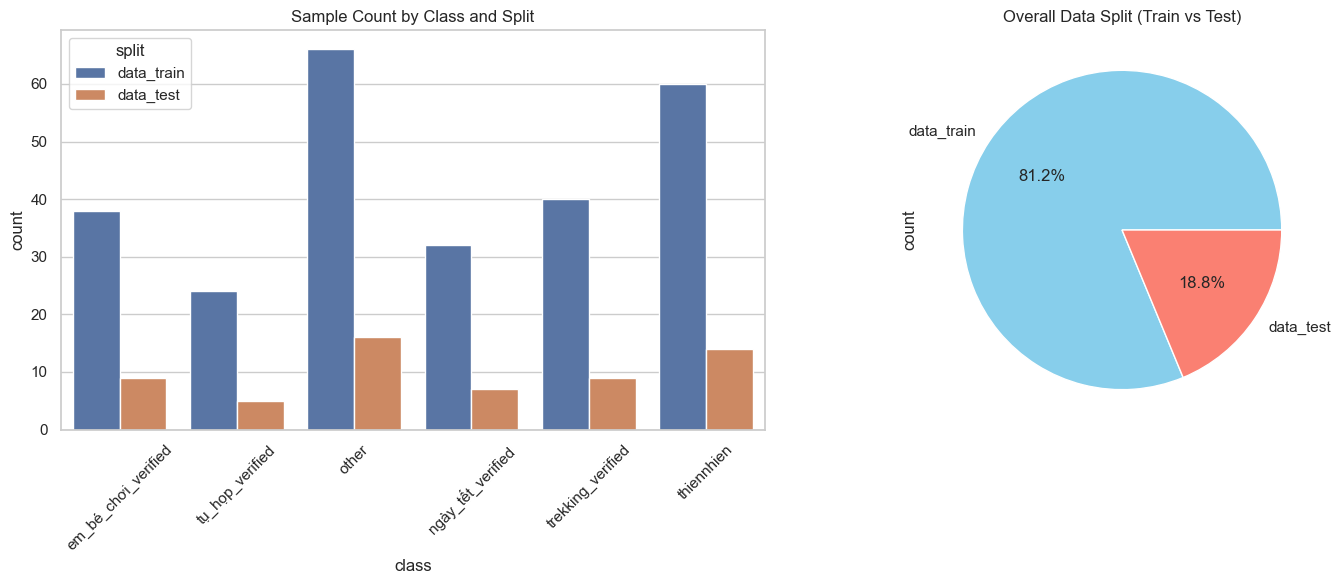

In [4]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='class', hue='split')
plt.title('Sample Count by Class and Split')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df['split'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Overall Data Split (Train vs Test)')

plt.tight_layout()
plt.show()

## 4. Training Set Quality: Duplicate Analysis

Checking for images that appear multiple times within the training set.

Number of intra-class duplicates: 0


Number of conflicts: 9


,class,filename,md5
139,ngày_tết_verified,0041_139944057583.jpg,139944057583d8b065db3a39f7b337d5
96,other,tet_0041_139944057583.jpg,139944057583d8b065db3a39f7b337d5
124,other,tet_0029_5402f43a6653.jpg,5402f43a66539dfee3c3f57060219886
130,ngày_tết_verified,0029_5402f43a6653.jpg,5402f43a66539dfee3c3f57060219886
85,other,tet_0008_8843ddf7b700.jpg,8843ddf7b700d8af1f0ef819633587f2
149,ngày_tết_verified,0008_8843ddf7b700.jpg,8843ddf7b700d8af1f0ef819633587f2
146,ngày_tết_verified,0034_a077e240af5b.jpg,a077e240af5b24a8df63b5833b900966
78,other,tet_0034_a077e240af5b.jpg,a077e240af5b24a8df63b5833b900966
134,ngày_tết_verified,0036_adb92c35a73c.jpg,adb92c35a73c51e2e39593799861816c
108,other,tet_0036_adb92c35a73c.jpg,adb92c35a73c51e2e39593799861816c


Decision: Automatically prioritizing specific label, marking 'other' for deletion.


Number of conflicts: 2


,class,filename,md5
45,tụ_họp_verified,tet_0019_adc22c4c73c9.jpg,adc22c4c73c93fadad2d5aa8fcfa1eef
152,ngày_tết_verified,0019_adc22c4c73c9.jpg,adc22c4c73c93fadad2d5aa8fcfa1eef
61,tụ_họp_verified,0271_ee5b330fe187.webp,ee5b330fe187509e9c1e1f218eba5290
154,ngày_tết_verified,0271_ee5b330fe187.webp,ee5b330fe187509e9c1e1f218eba5290


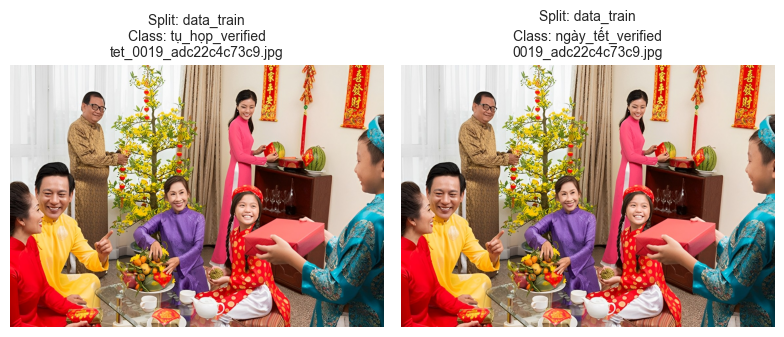

Paths involved for adc22c4c73c93fadad2d5aa8fcfa1eef:
'data_train/tụ_họp_verified/tet_0019_adc22c4c73c9.jpg'
'data_train/ngày_tết_verified/0019_adc22c4c73c9.jpg'


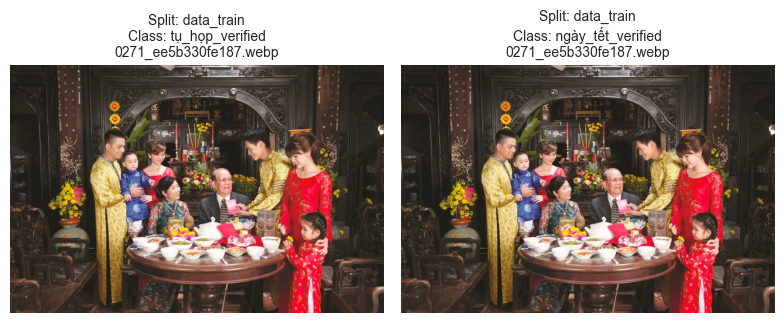

Paths involved for ee5b330fe187509e9c1e1f218eba5290:
'data_train/tụ_họp_verified/0271_ee5b330fe187.webp'
'data_train/ngày_tết_verified/0271_ee5b330fe187.webp'


In [5]:
to_delete_automated = []

# 4.1 Intra-class duplicates (Same Image, Same Class)
intra_dupes = train_df[train_df.duplicated(['class', 'md5'], keep=False)].sort_values(['class', 'md5'])
display(HTML("<h4>Case 1: Intra-class Duplicates (Same label, same content)</h4>"))
print(f"Number of intra-class duplicates: {intra_dupes['md5'].nunique()}")
if not intra_dupes.empty:
    display(intra_dupes[['class', 'filename', 'md5']])
    # Logic: Keep one, mark others for automated deletion
    for _, group in intra_dupes.groupby(['class', 'md5']):
        to_delete_automated.extend(group.iloc[1:]['path'].tolist())

# 4.2 Inter-class conflicts (Same Image, Different Class)
inter_dupes_all = train_df[train_df.duplicated('md5', keep=False)].sort_values('md5')
if not inter_dupes_all.empty:
    inter_conflicts = []
    for md5, group in inter_dupes_all.groupby('md5'):
        if len(group['class'].unique()) > 1:
            inter_conflicts.append(group)
    
    if inter_conflicts:
        conflicts_df = pd.concat(inter_conflicts)
        
        # CASE 2: other vs Specific
        case2_df = conflicts_df[conflicts_df.groupby('md5')['class'].transform(lambda x: 'other' in x.values)]
        if not case2_df.empty:
            display(HTML("<h4>Case 2: Label Conflict ( 'other' vs Specific Label )</h4>"))
            print(f"Number of conflicts: {case2_df['md5'].nunique()}")
            display(case2_df[['class', 'filename', 'md5']])
            print("Decision: Automatically prioritizing specific label, marking 'other' for deletion.")
            to_delete_automated.extend(case2_df[case2_df['class'] == 'other']['path'].tolist())

        # CASE 3: Specific vs Specific (Requires Review)
        case3_df = conflicts_df[conflicts_df.groupby('md5')['class'].transform(lambda x: 'other' not in x.values)]
        if not case3_df.empty:
            display(HTML("<h4>Case 3: Label Conflict ( Specific vs Specific - REQUIRES REVIEW )</h4>"))
            print(f"Number of conflicts: {case3_df['md5'].nunique()}")
            case3_md5s = case3_df['md5'].unique()
            display(case3_df[['class', 'filename', 'md5']])

            display_conflict_images(case3_df, case3_md5s)
else:
    print("No inter-class label conflicts found.")

### Case 3 Manual Resolution Code
If you want to delete specific files from Case 3 above, paste their paths into the list below.

In [6]:
to_delete_manual_conflicts = [
    "data_train/tụ_họp_verified/tet_0019_adc22c4c73c9.jpg",
    "data_train/tụ_họp_verified/0271_ee5b330fe187.webp"
]

## 5. Data Leakage (Train vs Test)

Images present in both splits. These must be removed from `data_train` to ensure valid evaluation.

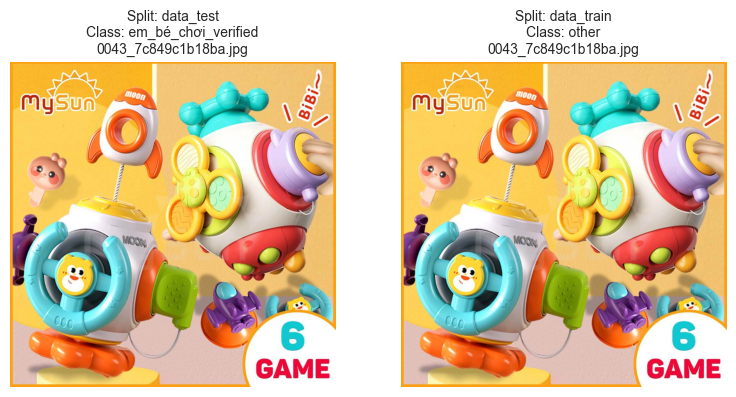

Paths involved for 7c849c1b18ba2364f7685f141b9d10c0:
'data_test/em_bé_chơi_verified/0043_7c849c1b18ba.jpg'
'data_train/other/0043_7c849c1b18ba.jpg'


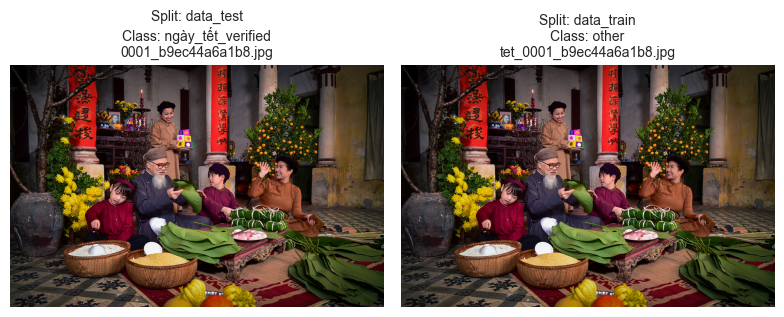

Paths involved for b9ec44a6a1b88590b1559b90fcc39c4b:
'data_test/ngày_tết_verified/0001_b9ec44a6a1b8.jpg'
'data_train/other/tet_0001_b9ec44a6a1b8.jpg'


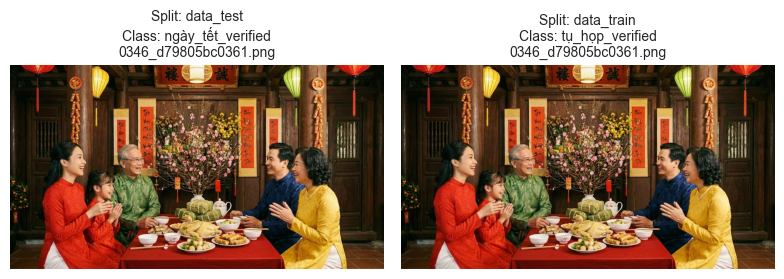

Paths involved for d79805bc0361d406460cb86d900befaf:
'data_test/ngày_tết_verified/0346_d79805bc0361.png'
'data_train/tụ_họp_verified/0346_d79805bc0361.png'


In [7]:
leak_md5s = sorted(list(set(train_df['md5']).intersection(set(test_df['md5']))))
if leak_md5s:
    display(HTML("<h4 style='color:red;'>WARNING: Data Leakage Detected</h4>"))
    leakage_visual_df = df[df['md5'].isin(leak_md5s)].sort_values(['md5', 'split'])
    display_conflict_images(leakage_visual_df, leak_md5s)
else:
    print("No data leakage detected.")

### Leakage Deletion Code
Choose which files to remove from Train. (Usually all Train files appearing above should be removed).

In [9]:
to_delete_manual_leakage = [
    "data_test/em_bé_chơi_verified/0043_7c849c1b18ba.jpg",
    "data_train/other/tet_0001_b9ec44a6a1b8.jpg",
    "data_train/tụ_họp_verified/0346_d79805bc0361.png"
]

## 6. Final Cleaning Preview & Execution

Review the final list of files categorized for deletion.

In [10]:
final_to_delete = sorted(list(set(
    to_delete_automated + 
    to_delete_manual_conflicts + 
    to_delete_manual_leakage
)))

print(f"--- Cleaning Summary ---")
print(f"Automated (Case 1 & 2): {len(to_delete_automated)} files")
print(f"Manual (Case 3 Conflicts): {len(to_delete_manual_conflicts)} files")
print(f"Manual (Data Leakage): {len(to_delete_manual_leakage)} files")
print(f"Total unique files to delete: {len(final_to_delete)}")

if final_to_delete:
    print("\nPreview of files for deletion:")
    for p in final_to_delete:
        print(f" - {p}")
    
    for p in final_to_delete:
        if os.path.exists(p):
            os.remove(p)
    print("\nCleanup complete.")

--- Cleaning Summary ---
Automated (Case 1 & 2): 9 files
Manual (Case 3 Conflicts): 2 files
Manual (Data Leakage): 3 files
Total unique files to delete: 14

Preview of files for deletion:
 - data_test/em_bé_chơi_verified/0043_7c849c1b18ba.jpg
 - data_train/other/0036_f4a414c4155d.png
 - data_train/other/tet_0001_b9ec44a6a1b8.jpg
 - data_train/other/tet_0008_8843ddf7b700.jpg
 - data_train/other/tet_0029_5402f43a6653.jpg
 - data_train/other/tet_0034_a077e240af5b.jpg
 - data_train/other/tet_0036_adb92c35a73c.jpg
 - data_train/other/tet_0039_ebcc1cb8283f.png
 - data_train/other/tet_0041_139944057583.jpg
 - data_train/other/tet_0044_fd6e6bcb0c74.jpg
 - data_train/other/tet_0047_eb58072fa128.webp
 - data_train/tụ_họp_verified/0271_ee5b330fe187.webp
 - data_train/tụ_họp_verified/0346_d79805bc0361.png
 - data_train/tụ_họp_verified/tet_0019_adc22c4c73c9.jpg

Cleanup complete.


Total images found: 306


,split,class,filename,path,width,height,aspect_ratio,mode,format,md5,size_kb
0,data_train,em_bé_chơi_verified,0020_d10406b35ffc.jpg,data_train/em_bé_chơi_verified/0020_d10406b35f...,626,416,1.50,RGB,JPEG,d10406b35ffcb8fd51502150320607bc,100.515625
1,data_train,em_bé_chơi_verified,0033_dc8d732281ba.jpg,data_train/em_bé_chơi_verified/0033_dc8d732281...,1200,628,1.91,RGB,JPEG,dc8d732281ba5c593e327b4145e07305,126.458008
2,data_train,em_bé_chơi_verified,0016_2d56040e719c.jpg,data_train/em_bé_chơi_verified/0016_2d56040e71...,1000,667,1.50,RGB,JPEG,2d56040e719ce405da3e88467dd457a5,92.551758
3,data_train,em_bé_chơi_verified,0044_9f0099b723af.jpg,data_train/em_bé_chơi_verified/0044_9f0099b723...,1280,720,1.78,RGB,JPEG,9f0099b723af39a52b71490c0da91189,119.230469
4,data_train,em_bé_chơi_verified,0030_c96cf87c1d08.webp,data_train/em_bé_chơi_verified/0030_c96cf87c1d...,399,208,1.92,RGB,WEBP,c96cf87c1d0899ba7e47525758130321,126.550781


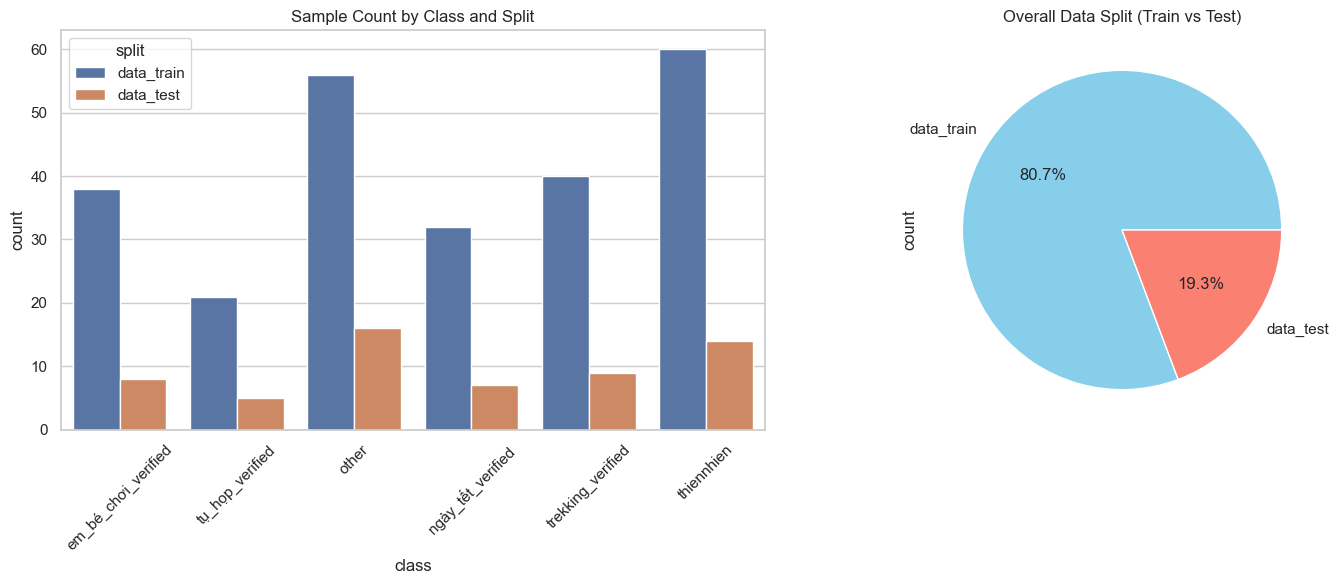

In [11]:
train_df = scan_dataset('data_train')
test_df = scan_dataset('data_test')
df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Total images found: {len(df)}")
display(df.head())

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='class', hue='split')
plt.title('Sample Count by Class and Split')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df['split'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Overall Data Split (Train vs Test)')

plt.tight_layout()
plt.show()

## 7. Data Preprocessing

Standardizing the dataset to ensure compatibility with modern deep learning models. Key steps include:
1. **Uniform Format**: Converting all images to `.jpg`.
2. **Color Space**: Converting all images to 3-channel RGB.
3. **Resolution**: Resizing to a fixed 224x224 size.

In [12]:
train_df = scan_dataset('data_train')
test_df = scan_dataset('data_test')
df = pd.concat([train_df, test_df], ignore_index=True)

In [13]:
import shutil

PROCESSED_DIR = 'processed_data'
if os.path.exists(PROCESSED_DIR):
    shutil.rmtree(PROCESSED_DIR)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f"Base directory for processed data created: {PROCESSED_DIR}")

Base directory for processed data created: processed_data


In [14]:
def preprocess_image(src_path, dest_path, size=(224, 224)):
    try:
        with Image.open(src_path) as img:
            # 1. Convert to RGB (handles RGBA, Grayscale, etc.)
            img = img.convert('RGB')
            
            # 2. Resize with high quality resampling
            img = img.resize(size, Image.Resampling.LANCZOS)
            
            # 3. Save as JPEG
            img.save(dest_path, 'JPEG', quality=95)
            return True
    except Exception as e:
        print(f"Error processing {src_path}: {e}")
        return False

In [15]:
processed_records = []

for idx, row in df.iterrows():
    # Create class subdirectory in processed_data
    dest_dir = os.path.join(PROCESSED_DIR, row['split'], row['class'])
    os.makedirs(dest_dir, exist_ok=True)
    
    # Define output filename (always .jpg)
    base_name = os.path.splitext(row['filename'])[0] + '.jpg'
    dest_path = os.path.join(dest_dir, base_name)
    
    # Process image
    if preprocess_image(row['path'], dest_path):
        processed_records.append({
            'original_path': row['path'],
            'processed_path': dest_path,
            'class': row['class']
        })

print(f"Preprocessing complete. {len(processed_records)} images saved to {PROCESSED_DIR}.")

Preprocessing complete. 306 images saved to processed_data.


### 11.4 Verification: Before vs After

Comparing sample images to ensure preprocessing didn't introduce artifacts.

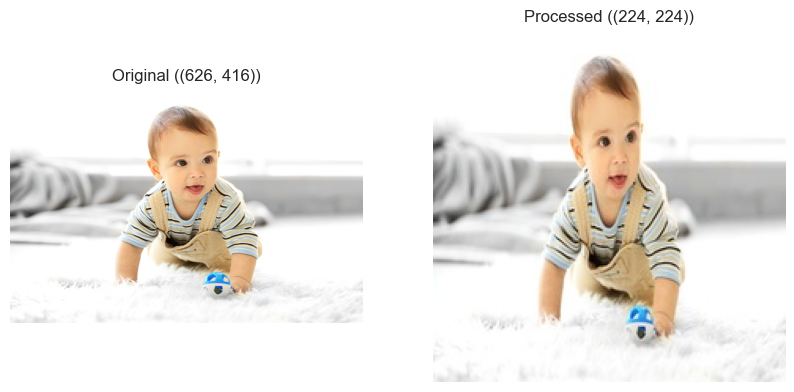

In [16]:
if processed_records:
    sample = processed_records[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Before
    img_before = Image.open(sample['original_path'])
    axes[0].imshow(img_before)
    axes[0].set_title(f"Original ({img_before.size})")
    axes[0].axis('off')
    
    # After
    img_after = Image.open(sample['processed_path'])
    axes[1].imshow(img_after)
    axes[1].set_title(f"Processed ({img_after.size})")
    axes[1].axis('off')
    
    plt.show()